# 3 · Why did the price move?

The question historical data cannot answer.

You can observe that a stock fell. You cannot observe that 60% of the fall
was order-flow pressure and the rest was noise, unless something computed
it, which is the case here.

In [1]:
import struct
import tradefloor as tf

print(f"the {len(tf.Engine.FACTORS)} factors:")
for f in tf.Engine.FACTORS:
    print("  ", f)

the 11 factors:
   reversion
   momentum
   crowd_lean
   company_news
   order_flow_impact
   short_squeeze_effect
   random_noise
   circuit_breaker
   jump
   overnight
   fair_value_shift


Four are shocks: `company_news`, `order_flow_impact`,
`short_squeeze_effect` and `random_noise`. Three are the model's own
dynamics: `reversion`, `momentum` and `crowd_lean`. The next three are event
columns. `circuit_breaker` books the correction the tick makes when the
session breaker clamps a price back into its band, and it does not fire in
the five-day run below. `jump` books the daily jump, which is applied after
the tick loop. On pt-v20, the default from 0.8.5, it also carries a small
daily compensator that keeps the jumps from adding a drift, which is the
+0.00020842 every name shows below on a day no jump fired (pt-v19:
+0.00041452). `overnight` books the move from one close to the next open,
and pt-v20 has none (`overnight_variance_ratio` is 0.0), so it reads zero.
They are columns so that the decomposition still adds up on the days they do
fire.

The last, `fair_value_shift`, is new in 0.8.5. pt-v20 moves each name's own
news and the stock- and sector-specific part of every shock into its fair
value rather than its mispricing, and this column books what left the
mispricing that way, with a minus sign. It is exactly zero on every preset
through pt-v19.

They accumulate per day and reset at market open, so reading after the close
gives you the day just finished.

**What they sum to matters more than it looks.** The eleven sum to the change
in `mispricing_s`, the log deviation of price from fair value, NOT to the
log price return. Fair value moves too, and that part of the price move is
not in these columns. On the run below the two rarely match in size and
differ in SIGN on five of the twenty: AAD's columns sum to -0.00662 while
its close-to-close log return is +0.00524, and AAG's sum to -0.00668
against +0.01938. So read the numbers as mispricing units, and read
the ranking and the signs, which the decomposition exists to give.

In [2]:
universe = tf.Universe.random(20, seed=111)
engine = tf.Engine(universe=universe, seed=3)
engine.run_days(5)

def attribution_table(engine):
    cols = {}
    for factor in tf.Engine.FACTORS:
        raw = engine.attribution(factor)
        cols[factor] = struct.unpack(f"<{len(raw) // 8}d", raw)
    rows = []
    for i, ticker in enumerate(engine.tickers):
        parts = {f: cols[f][i] for f in tf.Engine.FACTORS}
        rows.append({"ticker": ticker, "total": sum(parts.values()), **parts})
    return rows

rows = attribution_table(engine)
rows.sort(key=lambda r: -abs(r["total"]))
print(f"{len(rows)} instruments, biggest movers on day 5 first")

20 instruments, biggest movers on day 5 first


## Reading one name's day

The three biggest movers in mispricing terms, column by column, with each
column's share of the row total:

In [3]:
for r in rows[:3]:
    print(f"\n{r['ticker']}   day total, change in mispricing_s {r['total']:+.8f}")
    for f in tf.Engine.FACTORS:
        share = r[f] / r["total"] * 100 if r["total"] else 0.0
        bar = "#" * int(abs(share) / 4)
        print(f"    {f:22s} {r[f]:+.8f}  {share:6.1f}%  {bar}")
    residual = abs(sum(r[f] for f in tf.Engine.FACTORS) - r["total"])
    print(f"    {'residual':22s} {residual:.2e}")


AAM   day total, change in mispricing_s -0.00734638
    reversion              -0.00205519    28.0%  ######
    momentum               +0.00006802    -0.9%  
    crowd_lean             -0.00099409    13.5%  ###
    company_news           +0.00000000    -0.0%  
    order_flow_impact      +0.00000000    -0.0%  
    short_squeeze_effect   +0.00000000    -0.0%  
    random_noise           -0.00702714    95.7%  #######################
    circuit_breaker        +0.00000000    -0.0%  
    jump                   +0.00020842    -2.8%  
    overnight              +0.00000000    -0.0%  
    fair_value_shift       +0.00245360   -33.4%  ########
    residual               0.00e+00

AAN   day total, change in mispricing_s -0.00678396
    reversion              -0.00229838    33.9%  ########
    momentum               +0.00003230    -0.5%  
    crowd_lean             -0.00115891    17.1%  ####
    company_news           +0.00000000    -0.0%  
    order_flow_impact      +0.00000000    -0.0%  
    sh

The residual prints as `0.00e+00` on all three names, but read what it
compares. `total` in the table above is itself the sum of the eleven columns,
so each row is checked against its own sum and can only come out at zero.
What the line does confirm is that no column went missing between the engine
and the table.

The reconstruction it stands in for happens upstream, and fits nothing.
The engine books every increment into one of these eleven columns at the
moment it applies it, so this is its own bookkeeping rather than a
decomposition assembled afterwards.

The check with teeth is against `engine.truth()`: difference `mispricing_s`
across the day's ticks and add the eleven columns over the same ticks. They
agree to floating-point addition: this run, recorded day by day with
`record=True`, has a worst residual of 5.9e-17 over all 39,000 rows on
pt-v20. Against the
close-to-close log return they do not agree at all, which is the reason for
the note above.

## Across the whole roster

Aggregating the absolute contributions shows which mechanism is driving the
market on this day.

In [4]:
totals = {f: sum(abs(r[f]) for r in rows) for f in tf.Engine.FACTORS}
grand = sum(totals.values())

for f, v in sorted(totals.items(), key=lambda kv: -kv[1]):
    share = v / grand * 100
    print(f"  {f:22s} {share:5.1f}%  {'#' * int(share / 2)}")

  fair_value_shift        40.4%  ####################
  random_noise            40.0%  ###################
  reversion               12.1%  ######
  crowd_lean               6.1%  ###
  jump                     1.2%  
  momentum                 0.1%  
  company_news             0.0%  
  order_flow_impact        0.0%  
  short_squeeze_effect     0.0%  
  circuit_breaker          0.0%  
  overnight                0.0%  


## Plotting it

A stacked view of the same data:

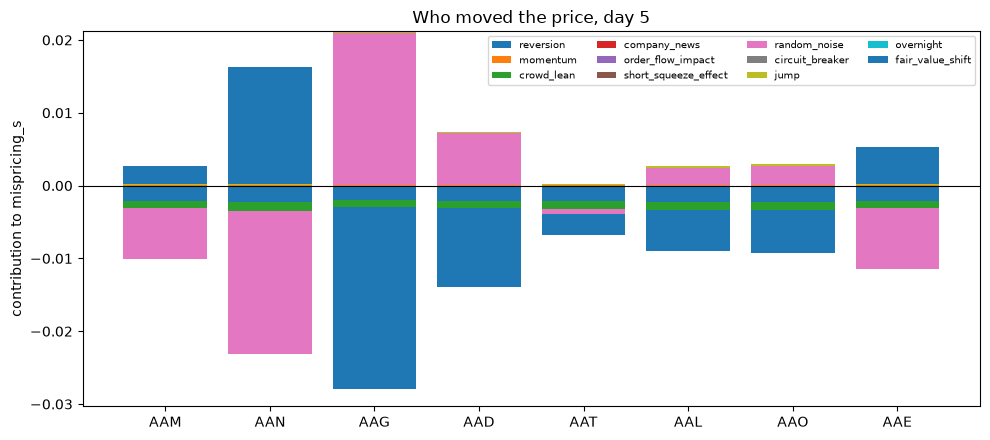

In [5]:
import matplotlib.pyplot as plt

top = rows[:8]
fig, ax = plt.subplots(figsize=(10, 4.5))
bottom_pos = [0.0] * len(top)
bottom_neg = [0.0] * len(top)

for factor in tf.Engine.FACTORS:
    vals = [r[factor] for r in top]
    bases = [bottom_pos[i] if v >= 0 else bottom_neg[i] for i, v in enumerate(vals)]
    ax.bar([r["ticker"] for r in top], vals, bottom=bases, label=factor)
    for i, v in enumerate(vals):
        if v >= 0:
            bottom_pos[i] += v
        else:
            bottom_neg[i] += v

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("contribution to mispricing_s")
ax.set_title("Who moved the price, day 5")
ax.legend(fontsize=7, ncol=4)
plt.tight_layout()
plt.show()

## What this is for

No historical source can provide this labelling. If you are training a model
to attribute moves, or checking that a factor decomposition recovers what
actually happened, the ground truth here is exact.

Two caveats:

- This is the simulator's own bookkeeping. It is exact for this model and
  says nothing about why a real stock moved.
- No agent traded above, so `order_flow_impact` is zero on every row: that
  column fills in only when orders reach the book. Run an evaluation to see
  a strategy's own footprint.

Next: **[4 · How realistic is this](04-how-realistic-is-this.ipynb)**.